---
title: "Data Cleaning and AI Statement"
---

## AI Statement

I did not use AI in this report, as stated at the beginning of the main report page. I think AI hinders learning, because it stops the brain from stretching and thinking about probelms. It is not as good of a writer as I am, so I have no need to use it in my writing. It is a better coder than I am, but that means I need to continue learning and memorizing the coding languages and tests that I want to perform. The only academic task I find AI suitable for is code debugging, but I also avoided that because I am trying to learn debugging on my own. Once I am confident in my abilities and fully understand the simpler tasks of coding, I would consider using AI to do more menial tasks that I am sure I do not need to supervise. Until then, I will continue to avoid using AI for academic projects. Instead, I used coursework, textbooks, documentation, unassisted web searches, and old school forum searches to find answers to my questions throughout the technical part of this project.

If I used AI, I could likely create more complex or more customized charts and objects. As it is, I am limited to my own creativity and (limited) knowledge of how these libraries are meant to function. I would also likely have completed this project faster, as I had to stop and look for directions many times per hour of work. It is a relatively simple and straightforward project, but I decided to be ambitious and implement Plotly to use the interactive charts we just learned about in DSAN 5200. In those ways, this project could have been better. I do not think this project would have necessarily been 'worse' if I used AI, because I would have been very strict with the outputs and adjusted them to my needs. However, that could potentially take more time than I spent looking up the correct inputs. I also would not have learned as much Plotly code as I did during the course of this project, which would be a detriment to my future success. I am pleased with my decision.

### Project Timeline
The following is a record of the project timeline.

January 29: 
- Researched and identified the College Scorecard dataset, and chose a loose topic around SAT test scores and admissions rates

February 4:
- Coordinated with Dani and Zoo Un to ensure that Dani and I had distinct projects, because we both wanted to use College Scorecard. We settled on different topics (institutional demand for the number of applicants, vs test scores), and different regions (Northeast vs Southeast, divided east coast states between us)

Febraury 5:
- Researched the SAT and other relevant topics
- Created GitHub pages for the final website report
- Cleaned the data for use
- Identified Fair Test's database on schools with test optional policies

February 10:
- Created most charts and graphics
- Drafted report text, and completed other research to finish the narrative
- Created first iteration of presentation slides

Februrary 11:
- Practiced and timed presentation slides
- Removed irrelevant presentation content; tightened narrative
- Finished all report text
- Citations, auxiliary pages, and technical details
- Continued practicing to reach desired time

February 12:
- Practiced and perfected slides
- Turned in slides and report


### Data Cleaning Log

This Jupyter Notebook contains all the information for cleaning and processing the data for the website report. The technical information about sourcing and preprocessing will be in this Notebook, and not in the official report content page. This project uses R primarily, through the Tidyverse package. This data cleaning log is not the prettiest one ever, and it is poorly commented. However, the cleaning process is relatively well documented, as are the relevant statistical tests. The charts were made using ggplot2, but the final iterations, as seen in the Report document, were generated using Plotly in R. The documentation for these charts are on the related github page for this project, under /docs/testing.qmd

In [3]:
##install.packages('tidyverse')
library('tidyverse')
library(colorspace)
dark_steelblue <- darken("steelblue4", 0.2)
sat_blue <- '#009bdb'

# Modern polished theme
theme_eda_modern <- theme(
  # Overall text
  text = element_text(family = "Helvetica", color = "black"),
  
  # Plot background
  plot.background = element_rect(fill = "white", color = NA),
  panel.background = element_rect(fill = "grey98", color = NA),
  
  # Gridlines
  panel.grid.major = element_line(color = "grey85"),
  panel.grid.minor = element_line(color = "grey90"),
  
  # Titles
  plot.title = element_text(size = 20, face = "bold", color = dark_steelblue, hjust = 0.5, margin = margin(b = 10)),
  plot.subtitle = element_text(size = 14, color = "grey30", hjust = 0.5, margin = margin(b = 10)),
  
  # Axis
  axis.title = element_text(size = 14, face = "bold", color = dark_steelblue),
  axis.text = element_text(size = 12, color = "grey20"),
  axis.ticks = element_line(color = "grey70"),
  
  # Legend
  legend.background = element_rect(fill = "grey98", color = NA),
  legend.key = element_rect(fill = "grey98"),
  legend.title = element_text(size = 14, face = "bold", color = dark_steelblue),
  legend.text = element_text(size = 12, color = "grey20"),
  legend.position = "top",
  legend.key.size = unit(1.2, "lines"),
  
  # Facets
  strip.background = element_rect(fill = "steelblue3", color = NA),
  strip.text = element_text(size = 14, face = "bold", color = "white"),
  
  # Margins
  plot.margin = margin(10, 10, 10, 10)
)

# Apply globally
theme_set(theme_eda_modern)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning messages:
1: package ‘tidyverse’ was built under R version 4.5.2 
2: package ‘ggplot2’ was built under R version 4.5.2 
3: package ‘tidyr’ was built under R version 4.5.2 
4: package ‘readr’ was built under R version 4.5.2 
5: package ‘dplyr’ was built under R version 4.5.2 
6: package ‘lubridate’ was built under R version 4.5.2 


In [52]:
## Loading the data
admin_df <- read_csv("Most-Recent-Cohorts-Institution.csv")

Rows: 6429 Columns: 3306
── Column specification ─────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2380): OPEID, OPEID6, INSTNM, CITY, STABBR, ZIP, ACCREDAGENCY, INSTURL, NPCURL, DEATH_YR2_RT...
dbl  (851): UNITID, SCH_DEG, HCM2, MAIN, NUMBRANCH, PREDDEG, HIGHDEG, CONTROL, ST_FIPS, REGION, L...
lgl   (75): LOCALE2, UG, UGDS_WHITENH, UGDS_BLACKNH, UGDS_API, UGDS_AIANOLD, UGDS_HISPOLD, UG_NRA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


First I will do an initial filtering and cleaning of the dataset. I want to specify the states and columns the project could be based off of. We also need to make sure that I have at least 200 usable schools.

In [53]:
## selecting the states I want
states <- c('DC','DE','FL','GA','MD','NC','PA','SC','VA','WV')
cleaning <- admin_df |> filter(STABBR %in% states)

## and making sure we have values in the admissions rate column
cleaning <- cleaning |> filter(!is.na(ADM_RATE))

#there are 3306 columns, we do not need that many.
#Unit ID for the university, institution name, city, state, zip code, highest degree awarded,
#  fips code for state, lat and long coordinates, locale of institution (city, rural), 
# admission rate,
# SAT midpoints for critical thinking, reading, and writing, and average total
# ACT midpoints for english, math, and writing, and the midpoint cumulative score,
# Completion rate for first-time, full-time students at four-year institutions (150% of expected time to completion)
# total share of undergrad enrollment who are men, and women, and the net price, adn cost of attendance

columns_to_select <- c('UNITID','INSTNM','CITY','STABBR','ZIP','HIGHDEG',
  'ST_FIPS','LATITUDE','LONGITUDE','LOCALE','ADM_RATE','SATVRMID',
  'SATMTMID','SATWRMID','SAT_AVG', 'ACTCMMID','ACTENMID', 'ACTMTMID','ACTWRMID','C150_4',
  'UGDS_MEN', 'UGDS_WOMEN',"NPT4_PUB",'NPT4_PRIV', 'COSTT4_A')

cleaning <- cleaning |> select(all_of(columns_to_select))

print("Retained Columns:")
print(colnames(cleaning))

print(paste("Number of Schools:", nrow(cleaning)))
print("Columns with Missing Values: ")
colSums(is.na(cleaning))

[1] "Retained Columns:"
 [1] "UNITID"     "INSTNM"     "CITY"       "STABBR"     "ZIP"        "HIGHDEG"    "ST_FIPS"   
 [8] "LATITUDE"   "LONGITUDE"  "LOCALE"     "ADM_RATE"   "SATVRMID"   "SATMTMID"   "SATWRMID"  
[15] "SAT_AVG"    "ACTCMMID"   "ACTENMID"   "ACTMTMID"   "ACTWRMID"   "C150_4"     "UGDS_MEN"  
[22] "UGDS_WOMEN" "NPT4_PUB"   "NPT4_PRIV"  "COSTT4_A"  
[1] "Number of Schools: 486"
[1] "Columns with Missing Values: "


    UNITID     INSTNM       CITY     STABBR        ZIP    HIGHDEG    ST_FIPS   LATITUDE  LONGITUDE 
         0          0          0          0          0          0          0          0          0 
    LOCALE   ADM_RATE   SATVRMID   SATMTMID   SATWRMID    SAT_AVG   ACTCMMID   ACTENMID   ACTMTMID 
         0          0        233        233        272        194        244        258        259 
  ACTWRMID     C150_4   UGDS_MEN UGDS_WOMEN   NPT4_PUB  NPT4_PRIV   COSTT4_A 
       396         77          0          0        327        174         48 

We need to have SAT_AVG scores for every school in my small study, so we are going to drop all of the rows that have a 'NA' in that column, and the NA's in the Completed in 4 years column. I also see that almost no schools have the ACTWRMID or PRGMOFR column, so lets get rid of those. Because I don't have a conversion for the SAT to ACT, I'm also going to drop the ACT columns and extra SAT columns. 

In [54]:
cleaning <- cleaning |> drop_na(SAT_AVG) |> drop_na(C150_4) |> select( -ACTWRMID, -SATVRMID, -SATMTMID, -SATWRMID, -ACTENMID, -ACTMTMID,-ACTCMMID)
print(paste("Number of Schools:", nrow(cleaning)))
print("Columns with Missing Values: ")
colSums(is.na(cleaning))

[1] "Number of Schools: 287"
[1] "Columns with Missing Values: "


    UNITID     INSTNM       CITY     STABBR        ZIP    HIGHDEG    ST_FIPS   LATITUDE  LONGITUDE 
         0          0          0          0          0          0          0          0          0 
    LOCALE   ADM_RATE    SAT_AVG     C150_4   UGDS_MEN UGDS_WOMEN   NPT4_PUB  NPT4_PRIV   COSTT4_A 
         0          0          0          0          0          0        160        127          0 

In [55]:
# consolidating cost of attendance
cleaning <- cleaning |>
  mutate(
    NPT4_PUB = coalesce(NPT4_PUB, NPT4_PRIV)
  )

cleaning <- cleaning |>
  rename(Avg_Net_Price = NPT4_PUB) |> select(-NPT4_PRIV)

This leaves us a clean dataset with unique identifiers and location data for all 287 schools on the list. We also have the admission rates, the average SAT score of applicants, the completion rate for first-time, full-time students at four-year institutions (150% of expected time to completion), and the total share of undergrad enrollment who are men, and who are women. We should be able to make a pretty sophisticated report with this information. Lets save our updated CSV before we do any more exploration.

In [56]:
write_csv(cleaning, "cleaned_admin_df.csv")

Now that we have our clean dataset, we can start with some basic visualizations to make sure we have a proportional dataset

Rows: 287 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): INSTNM, CITY, STABBR, ZIP
dbl (14): UNITID, HIGHDEG, ST_FIPS, LATITUDE, LONGITUDE, LOCALE, ADM_RATE, S...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


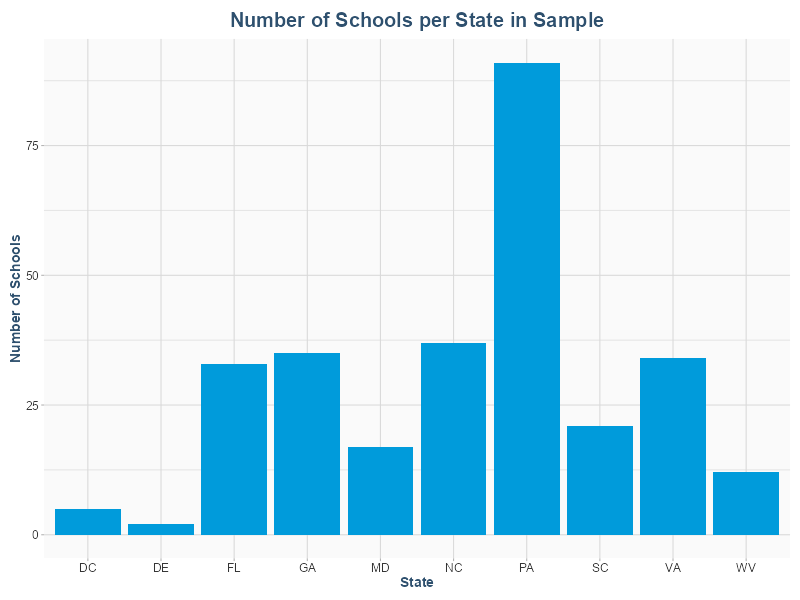

In [4]:
admin_df <- read_csv("cleaned_admin_df.csv")
ggplot(admin_df, aes(x=STABBR)) + 
  geom_bar(stat = "count", fill=sat_blue) + labs(
    title = "Number of Schools per State in Sample",
    x="State",
    y="Number of Schools"
  )

Pennsylvania has a lot more data than the others, so lets see if it's a lot of schools, or many campuses under one school.

In [4]:
print(admin_df$INSTNM[admin_df$STABBR == "PA"])

 [1] "Bryn Athyn College of the New Church"                         
 [2] "Allegheny College"                                            
 [3] "DeSales University"                                           
 [4] "Alvernia University"                                          
 [5] "Arcadia University"                                           
 [6] "Bryn Mawr College"                                            
 [7] "Bucknell University"                                          
 [8] "Cabrini University"                                           
 [9] "Carnegie Mellon University"                                   
[10] "Cedar Crest College"                                          
[11] "Chatham University"                                           
[12] "Delaware Valley University"                                   
[13] "Drexel University"                                            
[14] "Duquesne University"                                          
[15] "East Stroudsburg University 

Penn State has about 20 separate schools, each of which has its own statistics in the dataset. We have a few options. We could include these as-are, we could only count the main campus, or we could aggregate all of the statistics to an average of all the campuses. Most other states have about 20-30 schools, excluding DC and Delaware, which are both tiny. 

Penn State's various campuses seem to have different focuses, admission rates, and demographics of applicants, so we should probably keep all of them if we are going to compare admissions rates and school acceptances. Now lets look at the spread of our admission rates, SAT scores, proportions of men and women, and completion rates.

In [5]:
#distribution of admissions rates
p1 <- ggplot(admin_df, aes(x = ADM_RATE)) +
  geom_histogram(fill="steelblue3", col="black") +
  labs(title = "Distribution of Admissions Rates",
        x= "Admissions Rate", 
      y = "Frequency") +
  theme(
    plot.title = element_text(size = 14, face = "bold"), 
    axis.title = element_text(size = 12, face = "bold"), 
    axis.text = element_text(size = 10)                   
  )

#distribution of SAT scores
p2 <- ggplot(admin_df, aes(x = SAT_AVG)) +
  geom_histogram(fill="steelblue3", col="black") +
  labs(title = "Distribution of SAT Averages for Admitted Students",
        x= "SAT Average of Admitted Students", 
      y = "Frequency") +
  theme(
    plot.title = element_text(size = 14, face = "bold"), 
    axis.title = element_text(size = 12, face = "bold"), 
    axis.text = element_text(size = 10)                   
  )

#distribution of completion rates
p3 <- ggplot(admin_df, aes(x = C150_4)) +
  geom_histogram(fill="steelblue3", col="black") +
  labs(title = "Distribution of 6-year Completion Rates",
        x= "6-year Completion Rate", 
      y = "Frequency") +
  theme(
    plot.title = element_text(size = 14, face = "bold"), 
    axis.title = element_text(size = 12, face = "bold"), 
    axis.text = element_text(size = 10)                   
  )

# proportion of women (which is the inverse of the proportion of men)
p4 <- ggplot(admin_df, aes(x = UGDS_WOMEN)) +
  geom_histogram(fill="steelblue3", col="black") +
  labs(title = "Distribution of Female Enrolled Student Proportions",
        x= "Proportion of Female Enrolled Students", 
      y = "Frequency") +
  theme(
    plot.title = element_text(size = 14, face = "bold"), 
    axis.title = element_text(size = 12, face = "bold"), 
    axis.text = element_text(size = 10)                   
  )



`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


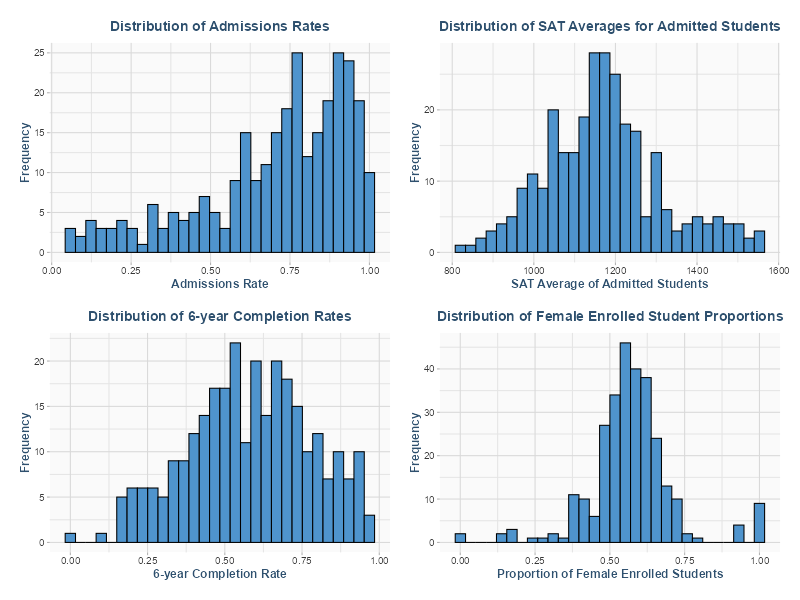

In [181]:
# combine and display plots
#install.packages("patchwork")
library('patchwork')
combined_plot <- (p1 + p2) / (p3 + p4)

# Print the combined plot
print(combined_plot)

#this would probably look better in python, but I think the website will use some plotly stuff if we can figure it out

I want to look at whether there is any correlation between SAT scores and admissions rates, and the proportion of female enrolled students. Then I want to see if either of those are at all related to the 6 year completion rate, and hopefully provide a recommendation whether to maintain or remove SAT test requirements.

We need to find out if high admissions rates are correlated with low SAT scores, and if low admissions rates are correlated with high SAT scores. (This seems obvious, but we should establish it)

Alright, lets see if admissoins rates are correlated with SAT scores. We will start with some statistical analysis

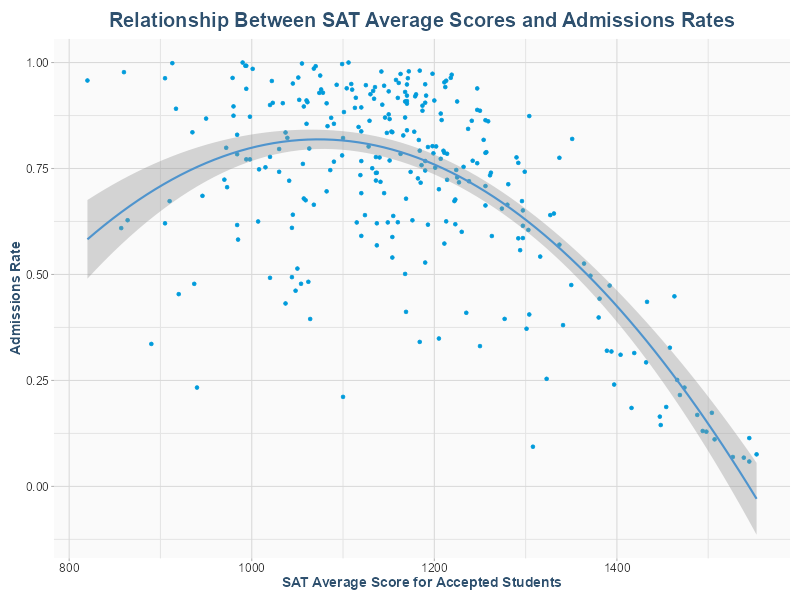

In [6]:
ggplot(admin_df, aes(x = SAT_AVG, y = ADM_RATE)) +
  geom_point(col=sat_blue) +
  labs(title = "Relationship Between SAT Average Scores and Admissions Rates",
        x= "SAT Average Score for Accepted Students", 
      y = "Admissions Rate")+
   geom_smooth(
    method = "lm",
    formula = y ~ x + I(x^2),
    se = TRUE, col = 'steelblue3'
  )

In [ ]:
correlation <- cor(admin_df$SAT_AVG, admin_df$ADM_RATE, method = 'pearson')
correlation

[1] -0.5716748

From this we see a moderate negative correlation. More selective schools (those with lower admissions rates) offer admission to students who have higher SAT scores. A large proportion of schools have higher accceptance rates, and accept more moderate SAT scores. Basically, fancy schools care, but the rest all hover around the same area.

Now lets see if SAT score has anything to do with the number of women enrolled

[1] -0.1036536


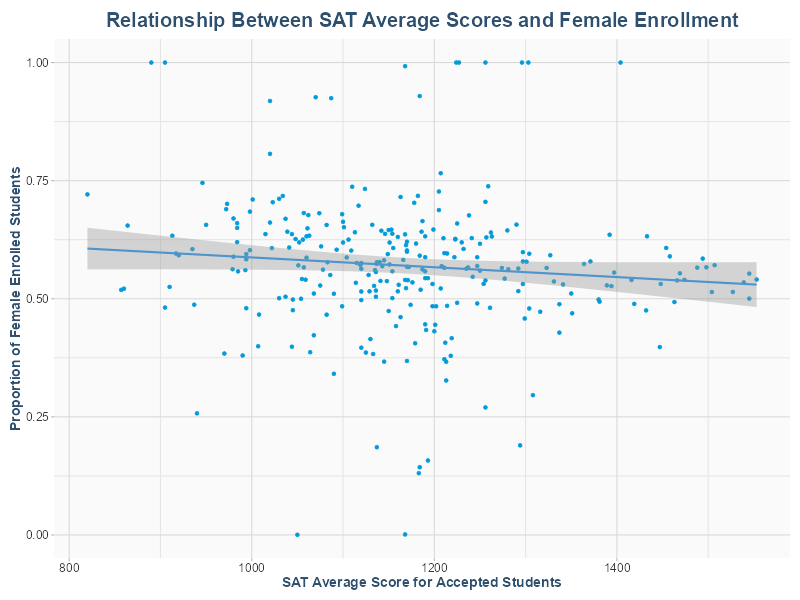

`geom_smooth()` using formula = 'y ~ x'

In [8]:
correlation <- cor(admin_df$SAT_AVG, admin_df$UGDS_WOMEN, method = 'pearson')
print(correlation)

ggplot(admin_df, aes(x = SAT_AVG, y = UGDS_WOMEN)) +
  geom_point(col=sat_blue) +
  labs(title = "Relationship Between SAT Average Scores and Female Enrollment",
        x= "SAT Average Score for Accepted Students", 
      y = "Proportion of Female Enrolled Students")+
   geom_smooth(
    method = "lm", col = 'steelblue3'
  )



There appears to be no relationship. Now lets try completion rates

[1] 0.7464987


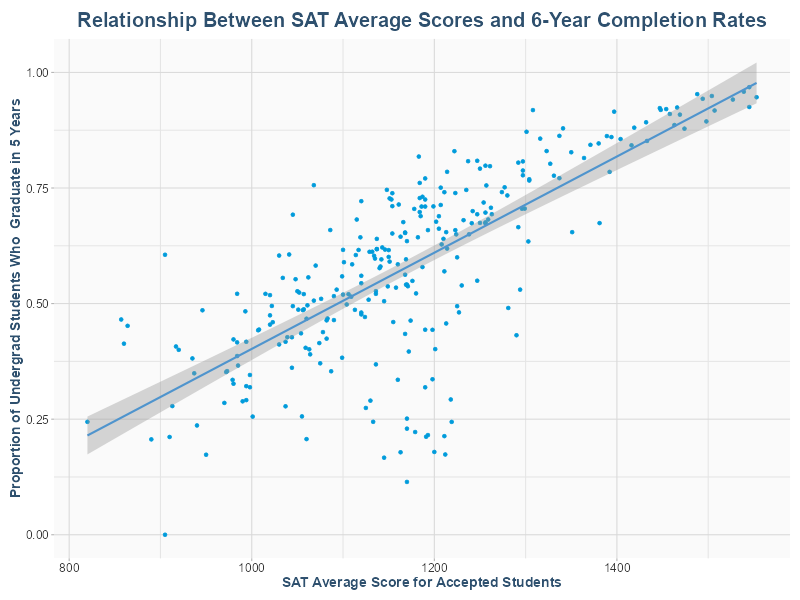

`geom_smooth()` using formula = 'y ~ x'

In [29]:
correlation <- cor(admin_df$SAT_AVG, admin_df$C150_4, method = 'pearson')
print(correlation)

ggplot(admin_df, aes(x = SAT_AVG, y = C150_4)) +
  geom_point(col=sat_blue) +
  labs(title = "Relationship Between SAT Average Scores and 6-Year Completion Rates",
        x= "SAT Average Score for Accepted Students", 
      y = "Proportion of Undergrad Students Who  Graduate in 5 Years")+
   geom_smooth(
    method = "lm", col = 'steelblue3'
  )



Ahhh, so SAT may predict whether students will graduate within 6 years, with a 0.74 correlation coefficient. Lets try with a real statistical test via linear regression

In [58]:
model <- lm(C150_4 ~ SAT_AVG, data = admin_df)
summary(model)


Call:
lm(formula = C150_4 ~ SAT_AVG, data = admin_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.46453 -0.04305  0.02926  0.07640  0.30244 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -6.383e-01  6.479e-02  -9.852   <2e-16 ***
SAT_AVG      1.040e-03  5.493e-05  18.940   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.133 on 285 degrees of freedom
Multiple R-squared:  0.5573,	Adjusted R-squared:  0.5557 
F-statistic: 358.7 on 1 and 285 DF,  p-value: < 2.2e-16


In [5]:
mean(admin_df$SAT_AVG, na.rm = TRUE)

[1] 1170.875

scaling for interpretability

In [59]:
admin_df$SAT_z <- scale(admin_df$SAT_AVG)

model_z <- lm(C150_4 ~ SAT_z, data = admin_df)
summary(model_z)


Call:
lm(formula = C150_4 ~ SAT_z, data = admin_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.46453 -0.04305  0.02926  0.07640  0.30244 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.579740   0.007853   73.82   <2e-16 ***
SAT_z       0.148996   0.007867   18.94   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.133 on 285 degrees of freedom
Multiple R-squared:  0.5573,	Adjusted R-squared:  0.5557 
F-statistic: 358.7 on 1 and 285 DF,  p-value: < 2.2e-16


When SAT scores are standardized, a one–standard deviation increase in a school’s average SAT score is associated with an approximately 15 percentage-point increase in six-year completion rates (p < 0.001). One standard deviation is about 150 SAT score points.

Let's try making a choropleth map of the admissions rates

In [32]:
library(sf)
library(dplyr)
library(mapview)
library(rnaturalearth)
library(rnaturalearthdata)

Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE
GDAL version >= 3.1.0 | setting mapviewOptions(fgb = TRUE)

Attaching package: ‘rnaturalearthdata’

The following object is masked from ‘package:rnaturalearth’:

    countries110



In [102]:
#install.packages("rnaturalearthhires",
                 #repos = "https://ropensci.r-universe.dev")

states_sf <- ne_states(
  country = "United States of America",
  returnclass = "sf"
)

states_sf <- states_sf |>
  filter(postal %in% states)

In [118]:
#joining the states data
admin_state <- admin_df |>
  filter(!is.na(ADM_RATE), !is.na(STABBR)) |>
  group_by(STABBR) |>
  summarise(
    avg_adm_rate = mean(ADM_RATE, na.rm = TRUE),
    n_schools = n(),
    .groups = "drop"
  )

states_map <- states_sf |>
  left_join(admin_state, by = c("postal" = "STABBR")) |>
  select(postal, avg_adm_rate, geometry)

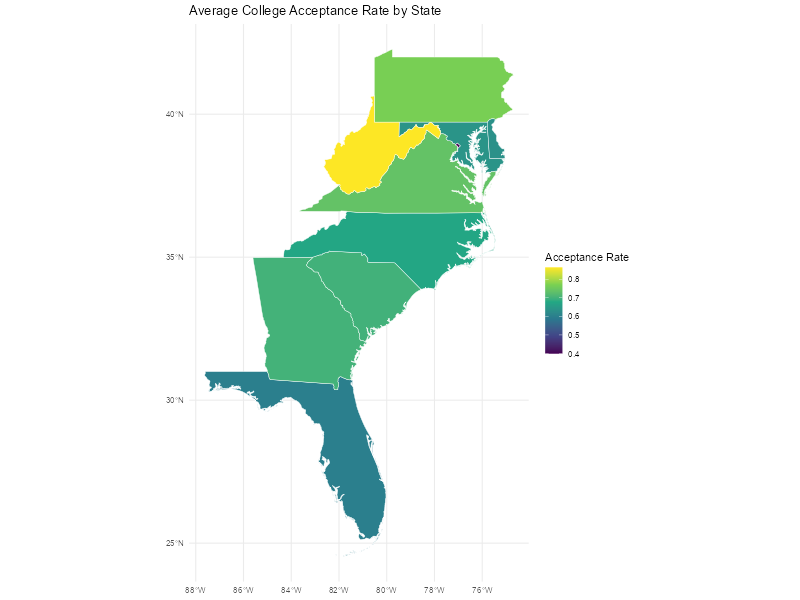

In [ ]:
ggplot(states_map) +
  geom_sf(aes(fill = avg_adm_rate), color = "white", linewidth = 0.2) +
  scale_fill_viridis_c(name = "Acceptance Rate") +
  theme_minimal() +
  labs(
    title = "Average College Admission Rates by State"
  )

That makes me happy, but we're not going to actually use it in the report, unfortunately

Lets see which schools appear on the test-free and test-optional list in 2026!
https://fairtest.org/test-optional-list/

In [60]:
# lets load that csv
tests_df <- read_csv("testoptionallist.csv")
tests_df <- tests_df |> filter(State %in% states)
institutions <- admin_df$INSTNM
tests_df <- tests_df |> filter(Institution_Name %in% institutions)
tests_df <- tests_df |> select(-Policy_Details, -Link_to_policy, -Control_of_institution)
head(tests_df)

Rows: 2089 Columns: 8
── Column specification ─────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (7): Institution_Name, State, Policy_2026, Is_policy_temporary, Link_to_policy, Pct_enroll_no...
num (1): Policy_Details

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 6 × 5
  Institution_Name                     State Policy_2026   Is_policy_temporary Pct_enroll_no_scores
  <chr>                                <chr> <chr>         <chr>               <chr>               
1 Abraham Baldwin Agricultural College GA    Test Optional Yes                 37%                 
2 Agnes Scott College                  GA    Test Optional No                  44%                 
3 Allegheny College                    PA    Test Optional No                  68%                 
4 Alvernia University                  PA    Test Optional Yes                 92%                 
5 American University                  DC    Test Optional No                  58%                 
6 Anderson University                  SC    Test Optional Unannounced         100%                

In [38]:
sapply(admin_test_df, class)

$UNITID
[1] "numeric"

$INSTNM
[1] "character"

$CITY
[1] "character"

$STABBR
[1] "character"

$ZIP
[1] "character"

$HIGHDEG
[1] "numeric"

$ST_FIPS
[1] "numeric"

$LATITUDE
[1] "numeric"

$LONGITUDE
[1] "numeric"

$LOCALE
[1] "numeric"

$ADM_RATE
[1] "numeric"

$SAT_AVG
[1] "numeric"

$C150_4
[1] "numeric"

$UGDS_MEN
[1] "numeric"

$UGDS_WOMEN
[1] "numeric"

$Avg_Net_Price
[1] "numeric"

$SAT_z
[1] "matrix" "array" 

$Policy_2026
[1] "character"

$Is_policy_temporary
[1] "character"

$Pct_enroll_no_scores
[1] "numeric"


In [61]:
admin_df <- admin_df |>
  mutate(
    SAT_z = as.numeric(SAT_z)
  )
class(admin_df$SAT_z)

[1] "numeric"

That dataset shows the schools that have test optional policies for students applying for Fall 2026. That is the majority of our list! Now we need to join this back to the other dataset and fill in the missing values

In [ ]:
admin_test_df <- admin_df |>
  left_join(
    tests_df, 
    by = c("INSTNM" = "Institution_Name")
  ) |> select(-State)

admin_test_df <- admin_test_df |>
  mutate(
    Policy_2026 = replace_na(Policy_2026, "Test Required")
  )

admin_test_df <- admin_test_df |>
  mutate(
    Pct_enroll_no_scores = as.numeric(gsub("%", "", Pct_enroll_no_scores)) / 100
  ) |>
  mutate(
    Pct_enroll_no_scores = replace_na(Pct_enroll_no_scores, 0)
  ) |>
  mutate(
    Is_policy_temporary = replace_na(Is_policy_temporary, "No")
  )

write_csv(admin_test_df, "admin_test_full.csv")
write_csv(admin_test_df, "admin_test_full.csv")
colnames(admin_test_df)

 [1] "UNITID"               "INSTNM"               "CITY"                 "STABBR"              
 [5] "ZIP"                  "HIGHDEG"              "ST_FIPS"              "LATITUDE"            
 [9] "LONGITUDE"            "LOCALE"               "ADM_RATE"             "SAT_AVG"             
[13] "C150_4"               "UGDS_MEN"             "UGDS_WOMEN"           "Avg_Net_Price"       
[17] "COSTT4_A"             "SAT_z"                "Policy_2026"          "Is_policy_temporary" 
[21] "Pct_enroll_no_scores"

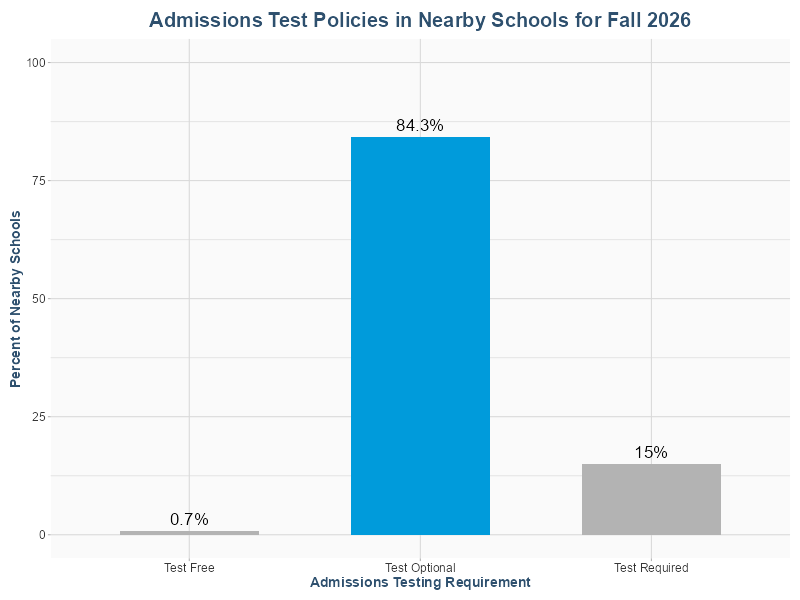

In [42]:
df_counts <- admin_test_df |>
  count(Policy_2026) |>
  mutate(pct = n / sum(n) * 100)

ggplot(df_counts, aes(x = Policy_2026, y = pct, fill = Policy_2026 == "Test Optional")) +
  geom_bar(stat = "identity", width=0.6) +
  geom_text(aes(label = paste0(round(pct, 1), "%")), 
            vjust = -0.5, size = 6) +
  scale_fill_manual(values = c("FALSE" = "grey70", "TRUE" = sat_blue),
                    guide = "none") +
  labs(
    title = "Admissions Test Policies in Nearby Schools for Fall 2026",
    x = "Admissions Testing Requirement",
    y = "Percent of Nearby Schools"
  ) +
  ylim(0, 100)

In [43]:
#testing plotly charts
# install.packages("plotly")
library(plotly)

#fitting a linear model
lm_fit <- lm(C150_4 ~ SAT_AVG, data = admin_df)

# Predict values along the range of SAT_AVG
sat_range <- seq(min(admin_df$SAT_AVG, na.rm = TRUE),
                 max(admin_df$SAT_AVG, na.rm = TRUE),
                 length.out = 100)

pred_df <- data.frame(
  SAT_AVG = sat_range,
  C150_4 = predict(lm_fit, newdata = data.frame(SAT_AVG = sat_range))
)

fig <- plot_ly(admin_df, 
               x = ~SAT_AVG, y = ~C150_4,
               type = 'scatter', mode = 'markers',
               marker = list(color = sat_blue),
               name = 'Schools') %>%
  add_trace(data = pred_df,
            x = ~SAT_AVG, y = ~C150_4,
            type = 'scatter', mode = 'lines',
            line = list(color = 'steelblue3', width = 2),
            name = 'Linear Trend') %>%
  layout(title = list(text = "Relationship Between SAT Average Scores and 6-Year Completion Rates",
                      font = list(size = 16)),
         xaxis = list(title = "SAT Average Score for Accepted Students"),
         yaxis = list(title = "Proportion of Undergrad Students Who Graduate in 6 Years",
                      tickformat = "%"))


Attaching package: ‘plotly’

The following object is masked from ‘package:ggplot2’:

    last_plot

The following object is masked from ‘package:stats’:

    filter

The following object is masked from ‘package:graphics’:

    layout



Warning message:
package ‘plotly’ was built under R version 4.5.2 


In [63]:
admin_df <- admin_df |>
  mutate(
    SAT_z = as.numeric(SAT_z)
  )
class(admin_df$SAT_z)

write_csv(admin_df,"cleaned_admin_df.csv")